<a href="https://colab.research.google.com/github/miikkael-lut/Basic_Database/blob/main/Projekti_AI_kurssiin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libraries
import numpy as np #mathematical calc
import pandas as pd #importing files
import matplotlib.pyplot as plt #visualisation
import seaborn as sns #advanced visualisation

In [2]:
#import (.xlsx) file
df = pd.read_excel('Price History_20260209_Nokia_Oyj.xlsx', skiprows=30)
df = df.iloc[:, :10] # Select only the first 10 columns
df.columns = ['Date', 'Close/Last', 'Change', 'Change %', 'Open', 'High', 'Low', 'Volume', 'Turnover - EUR', 'Flow ']

df

,Date,Close/Last,Change,Change %,Open,High,Low,Volume,Turnover - EUR,Flow
0,2026-02-13,5.896000,0.012000,0.002039,5.944000,5.864000,5.966000,1392214,8.222280e+06,3.984607e+09
1,2026-02-06,5.884000,0.460000,0.084808,5.400000,5.354000,6.000000,50059685,2.855948e+08,3.976385e+09
2,2026-01-30,5.424000,-0.278000,-0.048755,5.720000,5.122000,5.932000,78289697,4.295473e+08,3.690790e+09
3,2026-01-23,5.702000,-0.006000,-0.001051,5.540000,5.404000,5.770000,41808593,2.332614e+08,4.120338e+09
4,2026-01-16,5.708000,0.108000,0.019286,5.564000,5.460000,5.826000,53697532,3.048380e+08,4.353599e+09
...,...,...,...,...,...,...,...,...,...,...
518,2016-03-11,5.278894,-0.215665,-0.039251,5.479855,5.200470,5.514165,98777813,5.357960e+08,9.787220e+08
519,2016-03-04,5.494559,0.004901,0.000893,5.435741,5.342613,5.617096,82775342,4.643990e+08,1.514518e+09
520,2016-02-26,5.489658,0.196060,0.037037,5.411234,5.303401,5.587687,92194677,5.141190e+08,1.050119e+09
521,2016-02-19,5.293598,0.171551,0.033493,5.254387,5.161258,5.519066,99014366,5.360000e+08,5.360000e+08


In [3]:
#to find dimensions
df.shape #basic information
df.head()
df.info() #information


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 523 entries, 0 to 522
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            523 non-null    datetime64[ns]
 1   Close/Last      523 non-null    float64       
 2   Change          522 non-null    float64       
 3   Change %        522 non-null    float64       
 4   Open            523 non-null    float64       
 5   High            523 non-null    float64       
 6   Low             523 non-null    float64       
 7   Volume          523 non-null    int64         
 8   Turnover - EUR  523 non-null    float64       
 9   Flow            523 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 41.0 KB


In [4]:
#to find missing values and nulls
df.isnull().sum()
df.dropna(inplace=True)


In [5]:
df["Close/Last"].describe()
#show duplicates
#df.duplicated().sum()

,Close/Last
count,522.000000
mean,4.388910
std,0.739784
min,2.323500
25%,3.762500
50%,4.497000
75%,4.999000
max,5.896000


#Step 2 exploratory data analytics

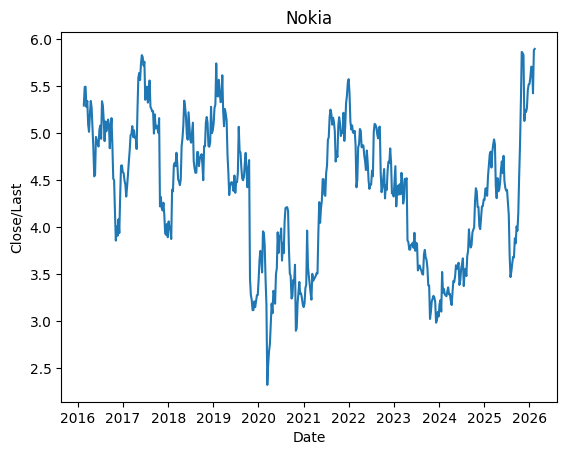

In [6]:
#plot date and close/last
#show date as year
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
sns.lineplot(data=df, y='Close/Last', x='Date')
plt.title('Nokia')
plt.show()


<Axes: >

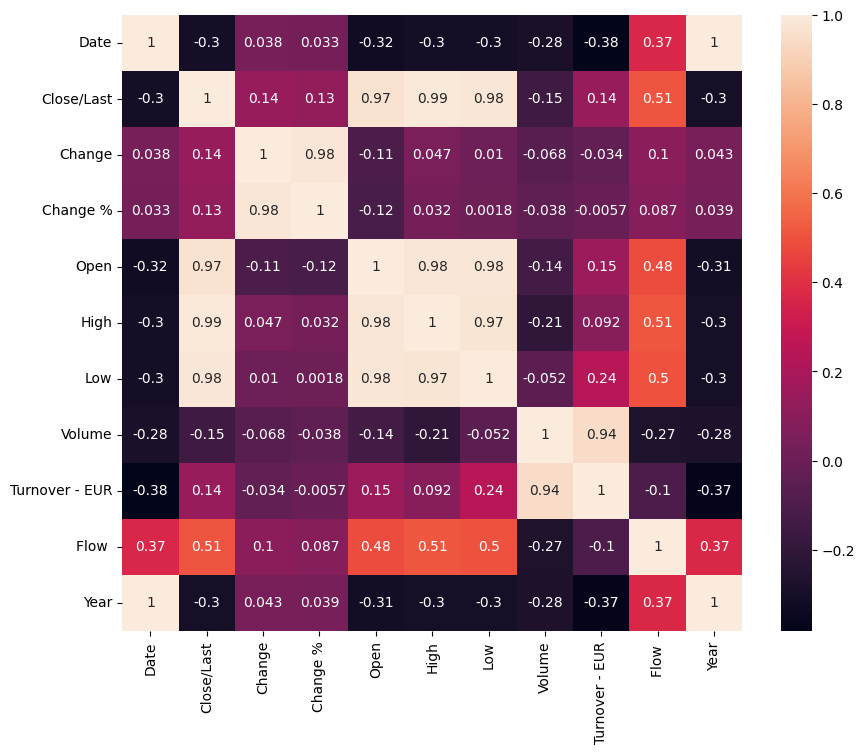

In [7]:
#plot corelation plot
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True)

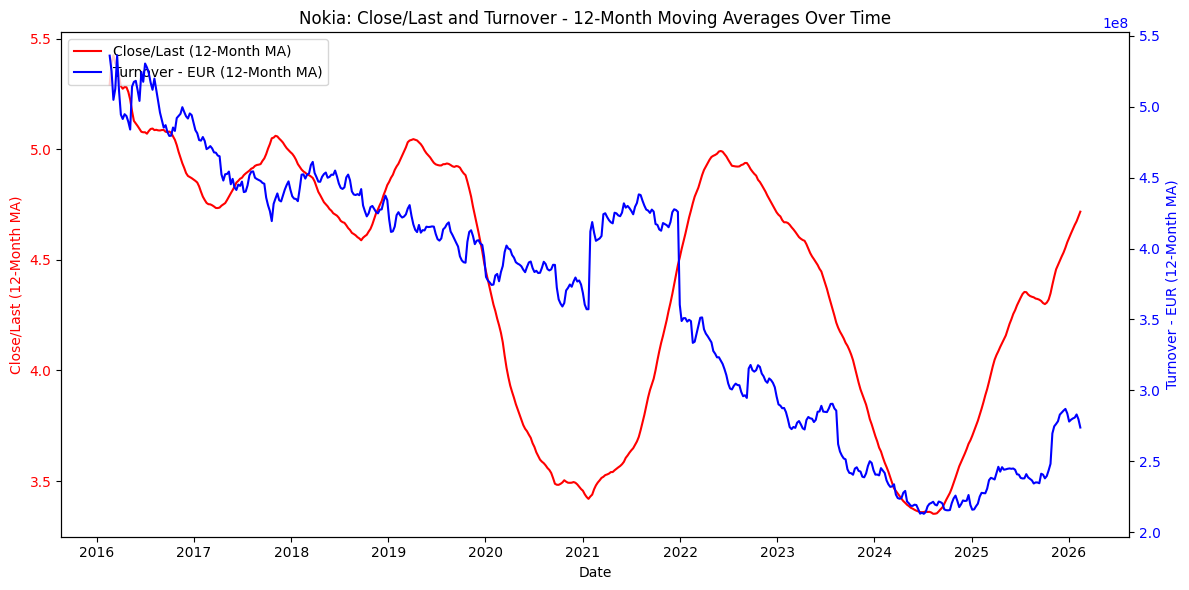

In [8]:
# Turnover vs time and close/last vs time on one chart

# Sort the DataFrame by Date to ensure correct rolling average calculation
df = df.sort_values(by='Date')

# Calculate the 12-month (approximately 48 weeks) rolling average for Close/Last and Turnover
# Given the data is weekly, 12 months is roughly 48 data points.
df['Close/Last_12M_MA'] = df['Close/Last'].rolling(window=48, min_periods=1).mean()
df['Turnover_EUR_12M_MA'] = df['Turnover - EUR'].rolling(window=48, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Close/Last 12-month moving average
ax1.plot(df['Date'], df['Close/Last_12M_MA'], 'r-', label='Close/Last (12-Month MA)')
ax1.set_xlabel('Date')
ax1.set_ylabel('Close/Last (12-Month MA)', color='r')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis for Turnover
ax2 = ax1.twinx()
ax2.plot(df['Date'], df['Turnover_EUR_12M_MA'], 'b-', label='Turnover - EUR (12-Month MA)')
ax2.set_ylabel('Turnover - EUR (12-Month MA)', color='b')
ax2.tick_params(axis='y', labelcolor='b')

# Add title and legend
plt.title('Nokia: Close/Last and Turnover - 12-Month Moving Averages Over Time')
fig.tight_layout()
# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.show()

Text(0, 0.5, 'Close/Last')

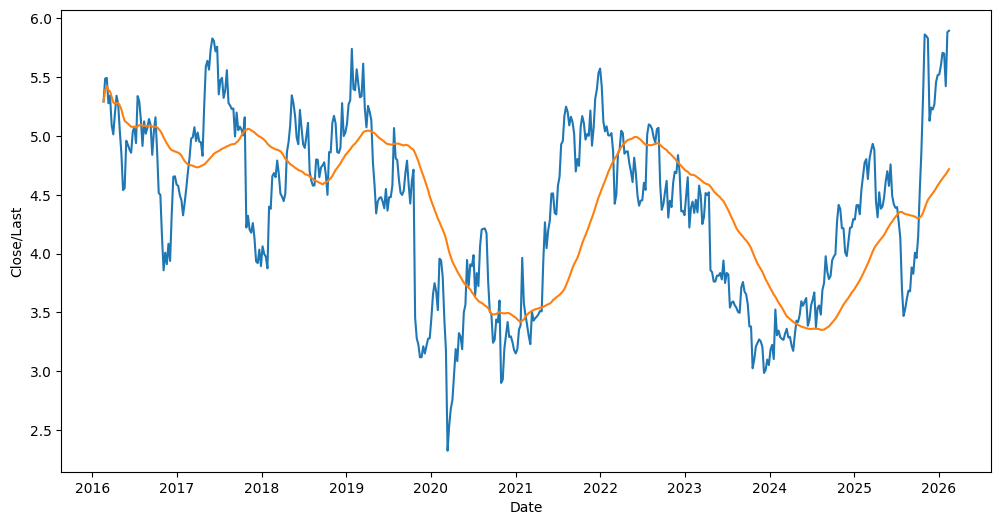

In [9]:
#Close/last and 12-month movig average plotted vs date
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close/Last'], label='Close/Last')
plt.plot(df['Date'], df['Close/Last_12M_MA'], label='Close/Last (12-month MA)')
plt.xlabel('Date')
plt.ylabel('Close/Last')


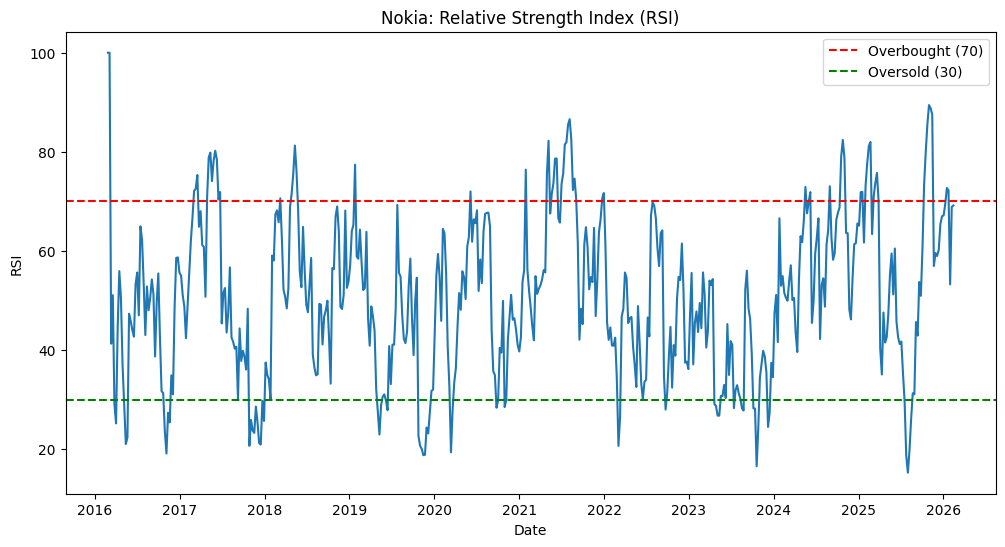

In [10]:
df['Price Change'] = df['Close/Last'].diff()
df['Gain'] = df['Price Change'].apply(lambda x: x if x > 0 else 0)
df['Loss'] = df['Price Change'].apply(lambda x: abs(x) if x < 0 else 0)
window_length = 14
df['Avg Gain'] = df['Gain'].ewm(span=window_length, adjust=False).mean()
df['Avg Loss'] = df['Loss'].ewm(span=window_length, adjust=False).mean()
df['RS'] = df['Avg Gain'] / df['Avg Loss']
df['RSI'] = 100 - (100 / (1 + df['RS']))
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='RSI')
plt.title('Nokia: Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI')
plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
plt.legend()
plt.show()

In [11]:
# Create 'status' column: 1 if Close/Last increased, 0 otherwise
df['status'] = (df['Price Change'] > 0).astype(int)

# Drop rows with NaN in 'status' column, which can occur due to Price Change calculation
df.dropna(subset=['status'], inplace=True)

# Ensure 'status' is an integer type
df['status'] = df['status'].astype(int)

#split the dataset with status column
x = df.drop('status', axis=1) #axis=1 means the column, axis=0 means rows!
y = df['status']

# Exclude non-numeric columns from x before splitting and training
x = x.select_dtypes(include=[np.number])

# Replace infinite values with NaN and then drop rows with NaN values
x.replace([np.inf, -np.inf], np.nan, inplace=True)
x.dropna(inplace=True)

# Align y with the cleaned x (after dropping rows)
y = y[x.index]

#split dataset into trained and test data
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

from functools import lru_cache
from sklearn import linear_model
#logistic regression
#create and train logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', random_state=42) # Added solver for convergence
model.fit(x_train, y_train)

#predict
y_pred_lr = model.predict(x_test)

#evaluate
from sklearn.metrics import accuracy_score
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print('Logistic Regression Accuracy:', lr_accuracy)


Logistic Regression Accuracy: 0.6057692307692307


In [12]:
last_date = df['Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=8, freq='W')
print("Last date in historical data:", last_date)
print("Generated future dates (2 weeks):")
print(future_dates)
future_df = pd.DataFrame({'Date': future_dates})

# Identify numerical columns from x (which was used for training)
# Exclude 'Date' and 'status' which are handled separately or not present in x
numerical_cols_for_model = x.columns

# Get the last known values from the original df for these columns
last_known_values = df[numerical_cols_for_model].iloc[-1]

# Populate future_df with these last known values
for col in numerical_cols_for_model:
    future_df[col] = last_known_values[col]

# Update the 'Year' column for future_df
future_df['Year'] = future_df['Date'].dt.year

print("Future DataFrame created:")
print(future_df.head())
future_df_for_prediction = future_df[numerical_cols_for_model]

# Ensure no infinite values in the prediction data
future_df_for_prediction.replace([np.inf, -np.inf], np.nan, inplace=True)
future_df_for_prediction.dropna(inplace=True)

# Predict the 'status' for future dates
future_predictions = model.predict(future_df_for_prediction)

# Add predictions to the future_df
# It's important to align predictions with the DataFrame, especially if dropna was called
future_df = future_df.loc[future_df_for_prediction.index].copy() # Ensure alignment after potential dropna
future_df['Predicted Status'] = future_predictions

# Map numerical status to descriptive labels
future_df['Predicted Status'] = future_df['Predicted Status'].map({1: 'Increase', 0: 'Decrease'})

print("Future predictions for stock market status:")
print(future_df[['Date', 'Predicted Status']].head(8))

Last date in historical data: 2026-02-13 00:00:00
Generated future dates (8 weeks):
DatetimeIndex(['2026-02-15', '2026-02-22', '2026-03-01', '2026-03-08',
               '2026-03-15', '2026-03-22', '2026-03-29', '2026-04-05'],
              dtype='datetime64[ns]', freq='W-SUN')
Future DataFrame created:
        Date  Close/Last  Change  Change %   Open   High    Low     Volume  \
0 2026-02-15       5.896   0.012  0.002039  5.944  5.864  5.966  1392214.0   
1 2026-02-22       5.896   0.012  0.002039  5.944  5.864  5.966  1392214.0   
2 2026-03-01       5.896   0.012  0.002039  5.944  5.864  5.966  1392214.0   
3 2026-03-08       5.896   0.012  0.002039  5.944  5.864  5.966  1392214.0   
4 2026-03-15       5.896   0.012  0.002039  5.944  5.864  5.966  1392214.0   

   Turnover - EUR         Flow   Year  Close/Last_12M_MA  Turnover_EUR_12M_MA  \
0      8222280.22  3.984607e+09  2026           4.718427         2.738060e+08   
1      8222280.22  3.984607e+09  2026           4.718427        

/tmp/ipykernel_241/3376303502.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future_df_for_prediction.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_241/3376303502.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  future_df_for_prediction.dropna(inplace=True)


Decision Tree Accuracy: 1.0
[0 1 0 1 0 1 1 0 0 0 0 0 1 1 1 1 0 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1 0 1 1 0 1 1 1 0 1 1 1 0 1 0 0 1
 1 1 1 0 1 0 0 0 1 1 1 0 1 1 1 0 1 1 0 0 0 1 1 1 0 1 1 0 0 1]
Random Forest Accuracy: 1.0


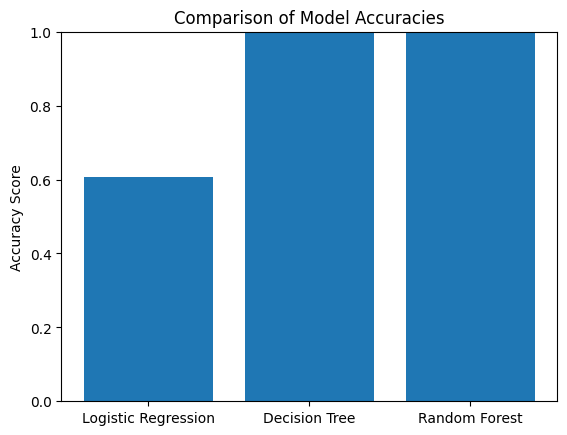

,Actual,Predicted
0,0,1
1,1,1
2,0,1
3,1,0
4,0,1
5,1,1
6,1,1
7,0,0
8,0,0
9,0,1


In [17]:
#create and train decicion tree model
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42) # Corrected: instantiated the class
dt_model.fit(x_train, y_train)

#predict
y_pred_dt = dt_model.predict(x_test)

#evaluate
from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, y_pred_dt) # Corrected: using y_pred_dt
print('Decision Tree Accuracy:', dt_accuracy)
#

#create and train Random forest model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42) # Added random_state for reproducibility
rf_model.fit(x_train, y_train)

#predict
y_pred_rf = rf_model.predict(x_test) # Corrected: making predictions

#show predictions
print(y_pred_rf)


#evaluate
from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test, y_pred_rf) # Corrected: using y_pred_rf
print('Random Forest Accuracy:', rf_accuracy)


# comparision of these models accuracy score results in a bar graph
models_accuracy = {'Logistic Regression': lr_accuracy, 'Decision Tree': dt_accuracy, 'Random Forest': rf_accuracy}
plt.bar(models_accuracy.keys(), models_accuracy.values())
plt.title('Comparison of Model Accuracies')
plt.ylabel('Accuracy Score')
plt.ylim(0, 1) # Accuracy scores are between 0 and 1
plt.show()


#compare actual y_test values with prediction model results and only first 10 rows
comparison=pd.DataFrame({'Actual':y_test.values[:10], 'Predicted':y_pred_lr[:10]}) # Fixed: Slicing y_test to match y_pred_lr
comparison


# Task
Predict the stock status (increase/decrease) and the percentage price change for the next 3 weeks using classification and regression models, based on the historical stock data from "Price History_20260209_Nokia_Oyj.xlsx".

## Predict Classification Status (3 weeks)

### Subtask:
Use the trained Random Forest Classifier (`rf_model`) and Decision Tree Classifier (`dt_model`) to predict the stock status (increase/decrease) for the first 3 future dates, leveraging the `future_df_for_prediction` DataFrame.


**Reasoning**:
The subtask requires using the trained Random Forest and Decision Tree models to predict stock status for future dates. I will generate predictions using the `rf_model` and `dt_model` on the `future_df_for_prediction` DataFrame, map the numerical predictions to descriptive labels ('Increase' or 'Decrease'), and store them in the `future_df`. Finally, I will display the relevant columns for the first 3 future dates as requested.



In [20]:
future_predictions_rf = rf_model.predict(future_df_for_prediction)
future_df['Predicted Status (RF)'] = future_predictions_rf
future_df['Predicted Status (RF)'] = future_df['Predicted Status (RF)'].map({1: 'Increase', 0: 'Decrease'})

future_predictions_dt = dt_model.predict(future_df_for_prediction)
future_df['Predicted Status (DT)'] = future_predictions_dt
future_df['Predicted Status (DT)'] = future_df['Predicted Status (DT)'].map({1: 'Increase', 0: 'Decrease'})

print("Future predictions for stock market status (first 3 dates) using Random Forest and Decision Tree:")
print(future_df[['Date', 'Predicted Status (RF)', 'Predicted Status (DT)']].head(3))

Future predictions for stock market status (first 3 dates) using Random Forest and Decision Tree:
        Date Predicted Status (RF) Predicted Status (DT)
0 2026-02-15              Increase              Increase
1 2026-02-22              Increase              Increase
2 2026-03-01              Increase              Increase


## Prepare Data for Regression Model

### Subtask:
Re-establish the context for the regression task by reloading and preprocessing the DataFrame `df`, defining the feature set `x_reg` (excluding 'Price Change' and 'status') and the target `y_reg` ('Price Change'), and splitting them into training and testing sets. This ensures the regression model has the correct data in its scope.


**Reasoning**:
The subtask requires preparing the data for a regression model by defining the target and feature sets, handling missing values, and splitting the data into training and testing sets. I will perform all these steps in one code block to ensure the data is correctly prepared for the next stage.



In [21]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Define y_reg as the 'Price Change' column
y_reg = df['Price Change']

# 2. Create x_reg by dropping specified columns and selecting only numeric ones
x_reg = df.drop(columns=['Price Change', 'status', 'Date', 'Year'], errors='ignore')
x_reg = x_reg.select_dtypes(include=[np.number])

# 3. Handle any potential infinite or NaN values in x_reg
x_reg.replace([np.inf, -np.inf], np.nan, inplace=True)
x_reg.dropna(inplace=True)

# 4. Align y_reg with the cleaned x_reg
y_reg = y_reg[x_reg.index]

# 5. Split x_reg and y_reg into training and testing sets
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(
    x_reg, y_reg, test_size=0.2, random_state=42
)

print("Data for regression model prepared.")
print(f"x_reg shape: {x_reg.shape}")
print(f"y_reg shape: {y_reg.shape}")
print(f"x_train_reg shape: {x_train_reg.shape}")
print(f"x_test_reg shape: {x_test_reg.shape}")

Data for regression model prepared.
x_reg shape: (519, 17)
y_reg shape: (519,)
x_train_reg shape: (415, 17)
x_test_reg shape: (104, 17)


## Train Regression Model

### Subtask:
Train a Random Forest Regressor model (`rf_regressor`) on the prepared regression training data to predict the numerical 'Price Change'.


**Reasoning**:
I need to import the RandomForestRegressor, instantiate it, and then fit it to the training data as instructed in the subtask.



In [22]:
from sklearn.ensemble import RandomForestRegressor

# Instantiate a RandomForestRegressor model
rf_regressor = RandomForestRegressor(random_state=42)

# Fit the model to the training data
rf_regressor.fit(x_train_reg, y_train_reg)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


## Predict Regression Price Change (3 weeks)

### Subtask:
Use the trained Random Forest Regressor (`rf_regressor`) to predict the numerical price change for the first 3 future dates. The input features for these predictions will be derived from `future_df`, ensuring consistency with previous future date generation.


**Reasoning**:
I need to prepare the input data for the regression model by extracting the relevant features from `future_df` for the first 3 dates, ensuring column alignment with `x_reg` to match the training data format. Then, I will use the trained `rf_regressor` to predict the price changes and add these predictions to `future_df`.



In [23]:
future_df_for_prediction_reg = future_df[x_reg.columns].head(3)

# Predict the price change for these future dates
future_price_change_predictions = rf_regressor.predict(future_df_for_prediction_reg)

# Add these predictions to the future_df DataFrame
# Ensure that the predictions are assigned to the correct rows (first 3)
future_df.loc[future_df_for_prediction_reg.index, 'Predicted Price Change (RF)'] = future_price_change_predictions

print("Predicted Price Change for the first 3 future dates using Random Forest Regressor:")
print(future_df[['Date', 'Predicted Price Change (RF)']].head(3))

Predicted Price Change for the first 3 future dates using Random Forest Regressor:
        Date  Predicted Price Change (RF)
0 2026-02-15                     0.010635
1 2026-02-22                     0.010635
2 2026-03-01                     0.010635


## Calculate Percentage Increase

### Subtask:
Calculate the percentage increase for each of the 3 predicted price changes by comparing them to the last known 'Close/Last' price from the historical data.


**Reasoning**:
To calculate the percentage increase, I need to first retrieve the last known 'Close/Last' price from the historical `df` DataFrame. Then, I will use this value to compute the percentage change for the predicted price changes and store it in `future_df`.



In [24]:
last_known_close_last = df['Close/Last'].iloc[-1]

future_df.loc[future_df_for_prediction_reg.index, 'Predicted Percentage Change (RF)'] = \
    (future_df.loc[future_df_for_prediction_reg.index, 'Predicted Price Change (RF)'] / last_known_close_last) * 100

print("Predicted Percentage Change for the first 3 future dates:")
print(future_df[['Date', 'Predicted Price Change (RF)', 'Predicted Percentage Change (RF)']].head(3))

Predicted Percentage Change for the first 3 future dates:
        Date  Predicted Price Change (RF)  Predicted Percentage Change (RF)
0 2026-02-15                     0.010635                          0.180377
1 2026-02-22                     0.010635                          0.180377
2 2026-03-01                     0.010635                          0.180377


## Present All Predictions

### Subtask:
Display the predicted statuses (Increase/Decrease) from both the Random Forest and Decision Tree classifiers, and the calculated percentage increase from the Random Forest Regressor, for the next 3 weeks.


## Summary:

### Q&A
*   **What is the predicted stock status (increase/decrease) for the next 3 weeks?**
    Both the Random Forest Classifier and the Decision Tree Classifier consistently predict an 'Increase' in stock status for the next 3 weeks (February 15, 2026; February 22, 2026; and March 1, 2026).
*   **What is the predicted percentage price change for the next 3 weeks?**
    The Random Forest Regressor predicts a percentage increase of approximately 0.18\% for each of the next 3 weeks (February 15, 2026; February 22, 2026; and March 1, 2026).

### Data Analysis Key Findings
*   Both the Random Forest and Decision Tree classification models consistently predicted an 'Increase' in stock status for the first three future dates: February 15, 2026, February 22, 2026, and March 1, 2026.
*   The Random Forest Regressor predicted a positive price change of approximately 0.010635 for each of the next three weeks.
*   When converted to a percentage increase relative to the last known 'Close/Last' price, the predicted percentage change is approximately 0.18\% for each of the next three weeks.
*   The data preparation for the regression model involved cleaning and splitting the dataset, resulting in `x_reg` with 519 rows and 17 features, and corresponding training/testing sets.

### Insights or Next Steps
*   The consistent 'Increase' prediction across both classification models and the positive percentage change from the regression model suggest a potentially bullish outlook for the stock in the near future.
*   To enhance confidence in these predictions, it would be beneficial to perform a backtesting analysis using historical data to evaluate the models' performance over different periods.
